In [ ]:
import pandas as pd

data = {
    "Student": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "J"],
    "Gender": ["Male", "Female", "Female", "Male", "Female", "Male",
               "Female", "Male", "Female", "Male", "Male"],
    "Study_Hours": [2, 4, 5, 3, 7, 6, 8, 100, 4, 5, 5],
    "Attendance": [75, 82, 90, 68, 88, 79, 95, 92, 70, None, 78],
    "Assignments": [70, 85, 88, 65, 92, 80, 96, 90, 72, 84, 84],
    "Marks": [48, 62, 71, 45, 85, 68, 91, 89, 52, 74, 74]
}

df = pd.DataFrame(data)

print(df)


   Student  Gender  Study_Hours  Attendance  Assignments  Marks
0        A    Male            2        75.0           70     48
1        B  Female            4        82.0           85     62
2        C  Female            5        90.0           88     71
3        D    Male            3        68.0           65     45
4        E  Female            7        88.0           92     85
5        F    Male            6        79.0           80     68
6        G  Female            8        95.0           96     91
7        H    Male          100        92.0           90     89
8        I  Female            4        70.0           72     52
9        J    Male            5         NaN           84     74
10       J    Male            5        78.0           84     74


In [ ]:
Q1 = df["Study_Hours"].quantile(0.25)
Q3 = df["Study_Hours"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Study_Hours"] < lower_bound) |
    (df["Study_Hours"] > upper_bound)
]

print(outliers)


  Student Gender  Study_Hours  Attendance  Assignments  Marks
7       H   Male          100        92.0           90     89


In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=["Gender"],
    drop_first=True
)

print(df_encoded.head())


  Student  Study_Hours  Attendance  Assignments  Marks  Gender_Male
0       A            2        75.0           70     48         True
1       B            4        82.0           85     62        False
2       C            5        90.0           88     71        False
3       D            3        68.0           65     45         True
4       E            7        88.0           92     85        False


Preprocessed training data:
[[ 0.53452248 -0.15116794 -0.08425178  1.        ]
 [-1.60356745 -0.59092923 -1.04712931  1.        ]
 [-0.53452248 -1.14063084 -0.8545538  -1.        ]
 [ 0.          1.0581756   0.68605024 -1.        ]
 [ 0.         -0.26110826  0.30089923  1.        ]
 [ 1.06904497  0.83829496  1.07120125 -1.        ]
 [-1.06904497 -1.36051149 -1.52856807  1.        ]
 [ 1.60356745  1.60787721  1.45635226 -1.        ]]

Testing data:
[[ 0.          0.01374254  0.30089923  1.        ]
 [-0.53452248  0.17865302  0.39718698 -1.        ]]


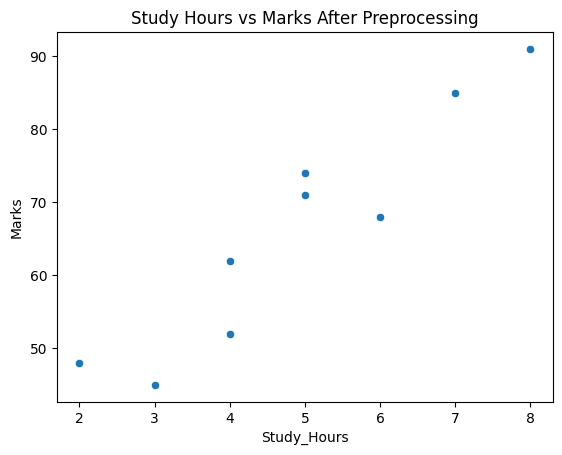

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create dataset
data = {
    "Student": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "J"],
    "Gender": ["Male", "Female", "Female", "Male", "Female", "Male",
               "Female", "Male", "Female", "Male", "Male"],
    "Study_Hours": [2, 4, 5, 3, 7, 6, 8, 100, 4, 5, 5],
    "Attendance": [75, 82, 90, 68, 88, 79, 95, 92, 70, None, 78],
    "Assignments": [70, 85, 88, 65, 92, 80, 96, 90, 72, 84, 84],
    "Marks": [48, 62, 71, 45, 85, 68, 91, 89, 52, 74, 74]
}

df = pd.DataFrame(data)

# 1. Handle missing values
df["Attendance"] = df["Attendance"].fillna(
    df["Attendance"].median()
)

# 2. Remove duplicate records
df = df.drop_duplicates()

# 3. Remove the assumed erroneous outlier
df = df[df["Study_Hours"] <= 8]

# 4. Encode categorical variable
df = pd.get_dummies(
    df,
    columns=["Gender"],
    drop_first=True
)

# 5. Separate features and target
X = df.drop(["Student", "Marks"], axis=1)
y = df["Marks"]

# 6. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 7. Scale numerical features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessed training data:")
print(X_train_scaled)

print("\nTesting data:")
print(X_test_scaled)

# 8. Visualization
sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Marks"
)

plt.title("Study Hours vs Marks After Preprocessing")
plt.show()
